In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import torch
import numpy as np
from nnfabrik.builder import get_data, get_trainer

from model import stacked_core_full_gauss_readout
from trainer import standard_trainer
from sensorium.utility.scores import get_correlations

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from mog_vae.model import MoGVAE

device = "cuda:7"
torch.cuda.set_device(device)

In [2]:
basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]


dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [3]:
model_config = {
    "pad_input": False,
    "stack": -1,
    "layers": 4,
    "input_kern": 9,
    "gamma_input": 6.3831,
    "gamma_readout": 0.0076,
    "hidden_kern": 7,
    "hidden_channels": 64,
    "depth_separable": True,
    "grid_mean_predictor": {
        "type": "cortex",
        "input_dimensions": 2,
        "hidden_layers": 1,
        "hidden_features": 30,
        "final_tanh": True,
    },
    "init_sigma": 0.1,
    "init_mu_range": 0.3,
    "gauss_type": "full",
    "shifter": True, 
    "autoencoder": None,
}

trainer_config = {
    'max_iter': 200,
    'verbose': False,
    'lr_decay_steps': 4,
    'avg_loss': False,
    'lr_init': 0.009,
    'device': device, 
}

In [4]:
model_seeds = [0, 1, 2]

In [5]:
from torch.nn import functional as F

def recon_loss_fn(x, x_rec):
    loss = (x - x_rec).pow(2).sum(-1)
    return loss.sum()

def log_normal(x, mu, var, eps=1e-8):
    var = var + eps
    return -0.5 * (np.log(2.0 * np.pi) + torch.log(var) + (x - mu).pow(2) / var).sum(dim=-1)

def gaussian_loss_fn(z, z_mu, z_var, z_mu_prior, z_var_prior):
    loss = log_normal(z, z_mu, z_var) - log_normal(z, z_mu_prior, z_var_prior)
    return loss.sum()

def entropy_loss_fn(logits, probs):
    log_q = F.log_softmax(logits, dim=-1)
    loss = (probs * log_q).sum(dim=-1)
    return loss.sum()

In [24]:
def train_autoenc(autoencoder, features, w_rec, w_gauss, w_entr_init, w_entr_decay, temp_init, temp_decay, temp_min, hard_softmax):
    autoencoder.train()
    optim = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, factor=0.3, patience=100)

    epochs = int(1e15)
    min_lr = 1e-5

    for epoch in range(epochs):
        temperature = max(temp_init * np.exp(-temp_decay * epoch), temp_min)
        model_out = autoencoder(features, return_params=True, temperature=temperature, hard=hard_softmax)
        
        recon = model_out['x_rec']
        recon_loss = recon_loss_fn(features, recon)

        z = model_out['z']
        z_mu, z_var = model_out['mu'], model_out['var']
        z_mu_prior, z_var_prior = model_out['y_mu'], model_out['y_var']
        gaussian_loss = gaussian_loss_fn(z, z_mu, z_var, z_mu_prior, z_var_prior)

        logits, probs = model_out['logits'], model_out['probs']
        entropy_loss = entropy_loss_fn(logits, probs)

        w_entr = w_entr_init * np.exp(-w_entr_decay * epoch)
        loss = w_rec * recon_loss + w_gauss * gaussian_loss + w_entr * entropy_loss

        optim.zero_grad()
        loss.backward()
        optim.step()
        scheduler.step(loss.item())
        if epoch % 100 == 0:
            lr = optim.param_groups[0]['lr']
            if lr < min_lr:
                break

            print(recon_loss.item(), gaussian_loss.item(), entropy_loss.item())
            print(lr, temperature, w_entr)

In [7]:
# Autoencoder configs for different latent dims that result in less than 1% performance drop
autoencoder_configs = [
    {'latent_dim': 64, 'hidden_dims': 128, 'hidden_layers': 1, },
    { 'latent_dim': 32, 'hidden_dims': 512, 'hidden_layers': 3, }, 
    { 'latent_dim': 16, 'hidden_dims': 512, 'hidden_layers': 5, }, 
    { 'latent_dim': 8, 'hidden_dims': 512, 'hidden_layers': 7, }, 
    #{ 'latent_dim': 4, 'hidden_dims': 1024, 'hidden_layers': 7, }, 
]

In [22]:
checkpoint = torch.load(f'checkpoints/base/model_weights{0}.pth')

# Extract features from all mice
features = []
for data_key in data_keys:
    features_single_mouse = checkpoint[f'readout.{data_key}._features']
    features_single_mouse = features_single_mouse.squeeze().permute(1, 0).detach()
    features.append(features_single_mouse)
features = torch.cat(features)

In [94]:
mog_vae = MoGVAE(64, 64, hidden_layers=2, hidden_dims=512, batch_norm=True, nonlinearity='GELU', num_components=10)
mog_vae.to(device)

MoGVAE(
  (inference): InferenceNet(
    (qyx_layers): ModuleList(
      (0): Linear(in_features=64, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): GumbelSoftmax(
        (logits): Linear(in_features=512, out_features=10, bias=True)
      )
    )
    (qzyx_layers): ModuleList(
      (0): Linear(in_features=74, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): Gaussian(
     

In [95]:
train_autoenc(mog_vae, features, w_rec=40, w_gauss=2, w_entr_init=2, w_entr_decay=2e-4, temp_init=1, temp_decay=2e-4, temp_min=0.1, hard_softmax=True)

2970822.25 2300655.5 -110725.3046875
0.001 1.0 2.0
174088.90625 1277460.75 -57867.546875
0.001 0.9801986733067553 1.9603973466135105
133698.96875 1425295.0 -58312.70703125
0.001 0.9607894391523232 1.9215788783046464
116278.90625 1518260.75 -59706.7265625
0.001 0.9417645335842487 1.8835290671684974
106809.8671875 1578335.0 -62458.203125
0.001 0.9231163463866358 1.8462326927732715
100655.96875 1620771.25 -65003.2265625
0.001 0.9048374180359595 1.809674836071919
96951.328125 1647349.875 -66754.2421875
0.001 0.8869204367171575 1.773840873434315
94714.3828125 1658660.125 -66936.546875
0.001 0.8693582353988059 1.7387164707976117
92742.953125 1669266.5 -66661.15625
0.001 0.8521437889662113 1.7042875779324227
91662.6875 1671716.0 -65599.3359375
0.001 0.835270211411272 1.670540422822544
90112.3125 1683645.25 -65268.0703125
0.001 0.8187307530779818 1.6374615061559636
90036.21875 1677439.875 -64920.48828125
0.001 0.8025187979624785 1.605037595924957
88842.6015625 1683192.5 -64041.8515625
0.001 0.

In [96]:
checkpoint = torch.load(f'checkpoints/base/model_weights{0}.pth')
model = stacked_core_full_gauss_readout(dataloaders, 0, **model_config)
model.load_state_dict(checkpoint)
model.eval()

validation_score = get_correlations(
    model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
)
print('base', validation_score)

mog_vae.eval()

for data_key in data_keys:
    model.readout[data_key].autoencoder = mog_vae

validation_score = get_correlations(
    model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
)
print(validation_score)

base 0.38690987
0.3600457


In [97]:
mog_vae.to(device)
mog_vae.eval()

MoGVAE(
  (inference): InferenceNet(
    (qyx_layers): ModuleList(
      (0): Linear(in_features=64, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): GumbelSoftmax(
        (logits): Linear(in_features=512, out_features=10, bias=True)
      )
    )
    (qzyx_layers): ModuleList(
      (0): Linear(in_features=74, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): Linear(in_features=512, out_features=512, bias=True)
      (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): GELU(approximate='none')
      (6): Gaussian(
     

In [98]:
model_out = mog_vae(features, temperature=1., hard=False, return_params=True)

In [99]:
# Cluster attribution numbers
y = model_out['y']
y = y.detach().cpu().numpy()
print(y[0])
y = y.argmax(axis=1)
[(y == i).sum(axis=0) for i in range(10)]

[2.4196167e-06 4.0624520e-05 6.2523311e-01 1.2496412e-05 7.5083482e-04
 1.1331704e-08 8.9944055e-04 3.8486210e-04 3.7267590e-01 2.3139668e-07]


[np.int64(4658),
 np.int64(12372),
 np.int64(4153),
 np.int64(4214),
 np.int64(3464),
 np.int64(5488),
 np.int64(3225),
 np.int64(4337),
 np.int64(9331),
 np.int64(3327)]

In [73]:
model_out['probs'][:10]

tensor([[2.9136e-10, 9.9433e-01, 5.2706e-10, 4.7655e-11, 1.4709e-11, 5.6439e-03,
         3.7245e-08, 2.4478e-05, 8.5694e-07, 1.8771e-10],
        [7.6174e-08, 9.9468e-01, 3.0478e-12, 3.8099e-12, 9.4778e-10, 9.7174e-06,
         2.2479e-12, 6.9936e-07, 5.3118e-03, 9.1062e-09],
        [2.3450e-04, 9.9941e-01, 2.3206e-09, 3.4337e-08, 3.6250e-06, 2.7890e-06,
         1.0826e-08, 4.8350e-06, 3.4236e-04, 7.0410e-10],
        [1.8717e-09, 5.9298e-04, 9.8572e-01, 8.9127e-13, 7.3281e-04, 2.7379e-06,
         9.8358e-14, 1.2947e-02, 3.7852e-10, 1.2291e-06],
        [1.0441e-06, 9.9940e-01, 6.2464e-09, 1.1822e-09, 6.6557e-09, 2.2888e-04,
         1.4583e-05, 4.3686e-05, 3.0628e-04, 1.2747e-06],
        [7.0387e-07, 9.9971e-01, 8.1850e-10, 2.6282e-08, 1.3747e-07, 3.0626e-11,
         6.9855e-10, 2.3086e-10, 2.8496e-04, 2.9686e-07],
        [5.9388e-09, 1.0000e+00, 1.1291e-06, 1.8699e-14, 3.8227e-11, 1.9595e-09,
         5.7604e-07, 5.6660e-11, 1.6582e-11, 2.5096e-14],
        [1.3705e-03, 9.8947

In [59]:
mu = model_out['y_mu']
var = model_out['y_var']

(mu[:, :, None] - mu[:, None, :]).mean(dim=2)

tensor([[ 0.4925,  0.4534,  0.5839,  ...,  0.9180, -0.4511, -0.4482],
        [ 0.4593,  0.4460,  0.5671,  ...,  0.8803, -0.4340, -0.4390],
        [ 0.4782,  0.4502,  0.5766,  ...,  0.9018, -0.4437, -0.4442],
        ...,
        [ 0.4677,  0.4479,  0.5713,  ...,  0.8898, -0.4383, -0.4413],
        [-1.1253, -0.5375, -0.3932,  ..., -0.9732,  0.3895,  0.0735],
        [ 0.1646,  0.3761,  0.4172,  ...,  0.5440, -0.2812, -0.3552]],
       device='cuda:7', grad_fn=<MeanBackward1>)

In [11]:
range_num_components = [5, 10, 15, 20, 25]

In [ ]:
# Train all autoencoders for each model

range_num_components = [5, 10, 15, 20, 25]
all_labels = []

for model_seed in model_seeds:
    checkpoint = torch.load(f'checkpoints/base/model_weights{model_seed}.pth')

    # Extract features from all mice
    features = []
    for data_key in data_keys:
        features_single_mouse = checkpoint[f'readout.{data_key}._features']
        features_single_mouse = features_single_mouse.squeeze().permute(1, 0).detach()
        features.append(features_single_mouse)
    features = torch.cat(features)

    label_dict = {}

    for autoencoder_config in autoencoder_configs:
        curve = []
        for num_components in range_num_components:
            print(num_components)
            autoencoder = MoGVAE(
                64, batch_norm=True, nonlinearity='GELU', num_components=num_components, **autoencoder_config
            )
            #autoencoder.load_state_dict(
            #    torch.load(f'checkpoints/autoencoder/model_weights{model_seed}_{autoencoder_config['latent_dim']}.pth')
            #)
            autoencoder.to(device)
            train_autoenc(autoencoder, features, w_rec=200, w_gauss=1, w_entr=2, temp_init=1, temp_decay=5e-4, temp_min=0.1, hard_softmax=True)
            torch.save(
                autoencoder.state_dict(), 
                f'checkpoints/mogvae/model_weights{model_seed}_{autoencoder_config['latent_dim']}_{num_components}.pth'
            )

            model_out = autoencoder(features, return_params=True, temperature=0.1, hard=True)
            y = model_out['y'].detach().cpu().numpy()
            _, labels = np.nonzero(y)
            curve.append(labels)

        label_dict[autoencoder_config['latent_dim']] = curve

    all_labels.append(label_dict)


with open('all_labels.pkl', 'wb') as f:
    pickle.dump(all_labels, f)

5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20
25
5
10
15
20


In [8]:
with open('all_labels.pkl', 'rb') as f:
    all_labels = pickle.load(f)

In [13]:
for model_seed in model_seeds:
    checkpoint = torch.load(f'checkpoints/base/model_weights{model_seed}.pth')
    model = stacked_core_full_gauss_readout(dataloaders, model_seed, **model_config)
    model.load_state_dict(checkpoint)
    model.eval()
    
    validation_score = get_correlations(
        model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
    )
    print('base', validation_score)

    for autoencoder_config in autoencoder_configs:
        for num_components in range_num_components:
            autoencoder = MoGVAE(
                64, batch_norm=True, nonlinearity='GELU', num_components=num_components, **autoencoder_config
            )

            checkpoint = torch.load(f'checkpoints/mogvae/model_weights{model_seed}_{autoencoder_config['latent_dim']}_{num_components}.pth')
            autoencoder.load_state_dict(checkpoint)
            autoencoder.eval()

            for data_key in data_keys:
                model.readout[data_key].autoencoder = autoencoder
        
            validation_score = get_correlations(
                model, dataloaders["validation"], device=device, as_dict=False, per_neuron=False
            )
            print(autoencoder_config['latent_dim'], num_components, validation_score)
    print()

/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:74: UserWarning: Use of 'gamma_readout' is deprecated. Use 'feature_reg_weight' instead. If 'feature_reg_weight' is defined, 'gamma_readout' is ignored
  warnings.warn(
/srv/user/nathanpaul.soeding/private_neuropredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


base 0.38690987
64 5 0.35443428
64 10 0.38688317
64 15 0.3869362
64 20 0.38675198
64 25 0.36942717
64 35 0.3855106
64 45 0.361403
64 60 0.3808383
64 75 0.37175477

base 0.3818726
64 5 0.36839762
64 10 0.37600073
64 15 0.36889142
64 20 0.37341413
64 25 0.37979707
64 35 0.36164957
64 45 0.3792691
64 60 0.3813421
64 75 0.3649891

base 0.37960163
64 5 0.368235
64 10 0.36129087
64 15 0.37697536
64 20 0.36508057
64 25 0.3696076
64 35 0.3693317
64 45 0.37777478
64 60 0.37343264
64 75 0.3744385



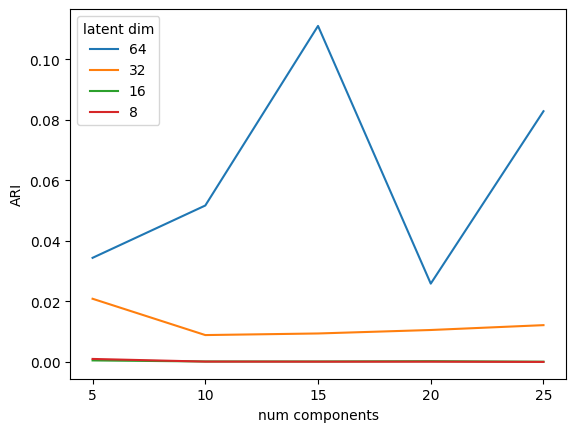

In [21]:
for latent_dim in [64, 32, 16, 8]:
    ari_curve = []
    for i in range(len(range_num_components)):
        ari = (
            adjusted_rand_score(all_labels[0][latent_dim][i], all_labels[1][latent_dim][i])
            + adjusted_rand_score(all_labels[0][latent_dim][i], all_labels[2][latent_dim][i])
            + adjusted_rand_score(all_labels[1][latent_dim][i], all_labels[2][latent_dim][i])
        ) / 3
        ari_curve.append(ari)

    plt.plot(range_num_components, ari_curve, label=latent_dim)
    plt.ylabel('ARI')
    plt.xlabel('num components')
    plt.xticks(range_num_components)
plt.legend(title='latent dim')
plt.savefig('plots/mogvae_64dim_ari.png')
plt.show()